# Final Project Part 1:

## Section 1:

For this project I wish to solve and analyze Option A. Or a tuned mass dampener. This ODE represents real world dampening of systems such as building vibrations or mechanical oscillators. However for this project I will be analyzing this equation in terms of Car suspension systems.

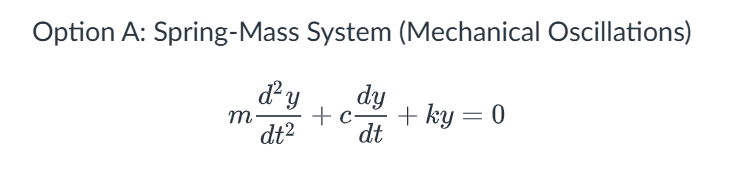

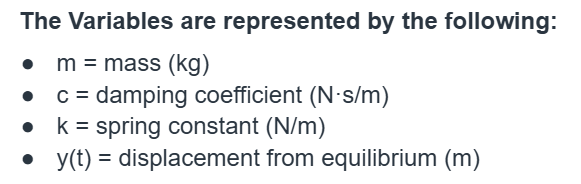

Solving to a system of first-order ODEs

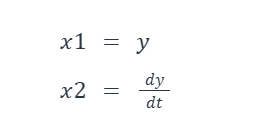

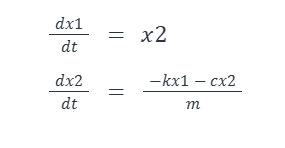

## Section 2:

Vehicle: 2014 Audi S4 (B8.5)

Mass (m): 1,750 kg (499 kg front / 376 kg rear per corner)

The curb weight is 1,750 kg. For a quarter-car model we split this per corner using a ~57/43 front/rear weight distribution typical of the quattro drivetrain: 499 kg front, 376 kg rear. 

Source: https://www.auto123.com/en/new-cars/technical-specs/audi/s4/2014/base/30-tfsi-quattro-progressiv/

Spring constant (k): Community-sourced data places the stock S4 spring rates at approximately 350 lb/in front and 290 lb/in rear. Converting to SI and applying the B8 platform's motion ratios (0.628 front, 0.60 rear from the Audi Revolution suspension thread) gives wheel rates of ~24,150 N/m front and ~18,290 N/m rear

Source: https://www.audiworld.com/forums/s4-b8-platform-discussion-134/adaptive-damping-suspension-2857459/

Damping coefficient (c): The S4's sport-tuned dampers target a damping ratio c ≈ 0.30 front / 0.28 rear (Audi specs for sport-biased sedans). Using c = 2c√(km) yields ~2,083 N·s/m front and ~1,468 N·s/m rear.

Source: https://www.audizine.com/threads/suspension-spring-rate.494793/

Initial conditions (speed bump): A standard US speed bump is ~90 mm tall. At a cautious crossing speed, this produces y(0) = 0.090 m and vertical velocity y_dot(0) = 0.3 m/s upward at each axle.

Source: I measured the speedbumps in my neighborhood

The physical system that is being modeled is a 2014 audi s4 traveling over a speed bump. This results in a vertical displacement, and a vertical velocity as an inital condition. Leading to our ODE to represent the resulting damped spring in accordance to the mass

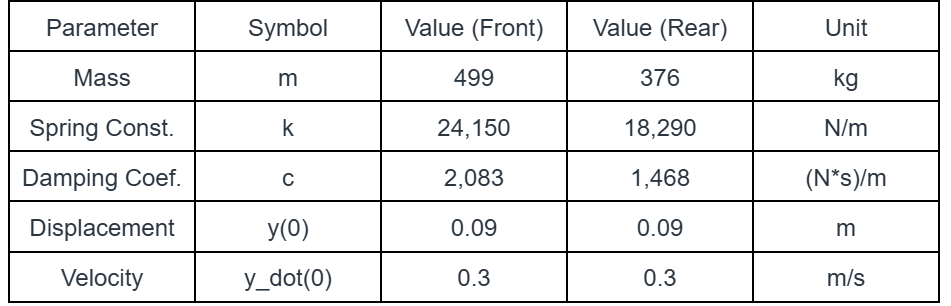

## Section 3:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Analysis of Audi s4 Hitting a speedbump: front and rear
    # Vehicle parameters (front quarter)
m = 499       # kg       — quarter-car mass
c = 2_083     # N·s/m   — damping coefficient 
k = 24_150    # N/m     — Spring Constant 

    # Vehicle parameters (rear quarter)
m0 = 376     # kg       — quarter-car mass
c0=1_468    # N·s/m   — damping coefficient
k0= 18_290   # N/m     — Spring Constant

    # Initial conditions (90mm speed bump)
y0 = 0.09   # m: initial displacement
v0 = 0.30     # m/s: Initial vertical velocity

T_END = 5.0  # s: Max time that will be simulated 


In [3]:
def f(t, y1, y2, m, k, c):
    return (-k * y1 - c * y2) / m

In [4]:
def euler_forward(m, k, c, y1_0, y2_0, t_end, h):
    """
    Solve  m*y'' + c*y' + k*y = 0  using Euler's Forward Method.
    """

    # Build uniform time grid from 0 to t_end with spacing h
    t  = np.arange(0, t_end + h, h)
    N  = len(t)
 
    # Pre-allocate arrays for both state variables
    y1 = np.zeros(N)
    y2 = np.zeros(N)
 
    # Set initial conditions at t = 0
    y1[0] = y1_0
    y2[0] = y2_0
 
    # Step forward in time
    for n in range(N - 1):
 
        # --- Euler update rule ---
        # slope for y1 is just y2 (definition of the state variable)
        # slope for y2 is f(t, y1, y2) — the ODE right-hand side
        y1[n + 1] = y1[n] + h * y2[n]
        y2[n + 1] = y2[n] + h * f(t[n], y1[n], y2[n], m, k, c)
 
    return t, y1, y2
 

In [5]:
def rk4(m, k, c, y1_0, y2_0, t_end, h):

    # Build uniform time grid
    t  = np.arange(0, t_end + h, h)
    N  = len(t)
 
    # Pre-allocate solution arrays
    y1 = np.zeros(N)
    y2 = np.zeros(N)
 
    # Set initial conditions
    y1[0] = y1_0
    y2[0] = y2_0
 
    # Step forward in time
    for n in range(N - 1):
 
        t_n  = t[n]
        y1_n = y1[n]
        y2_n = y2[n]
 
        # --- Four slope evaluations ---
 
        # k1: slope at the START of the interval
        k1_y1 = y2_n
        k1_y2 = f(t_n , y1_n , y2_n , m , k , c)
 
        # k2: slope at the MIDPOINT using k1 to estimate state there
        k2_y1 = y2_n + h/2 * k1_y2
        k2_y2 = f(t_n + h/2,   y1_n + h/2 * k1_y1, y2_n + h/2 * k1_y2, m, k, c)
 
        # k3: slope at the MIDPOINT again using k2 (corrected estimate)
        k3_y1 = y2_n + h/2 * k2_y2
        k3_y2 = f(t_n + h/2,   y1_n + h/2 * k2_y1, y2_n + h/2 * k2_y2, m, k, c)
 
        # k4: slope at the END of the interval using k3
        k4_y1 = y2_n + h * k3_y2
        k4_y2 = f(t_n + h, y1_n + h * k3_y1, y2_n + h * k3_y2, m, k, c)
 
        # --- Weighted average (weights: 1, 2, 2, 1) ---
        y1[n + 1] = y1_n + (h / 6) * (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1)
        y2[n + 1] = y2_n + (h / 6) * (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2)
 
    return t, y1, y2


## Section 4:

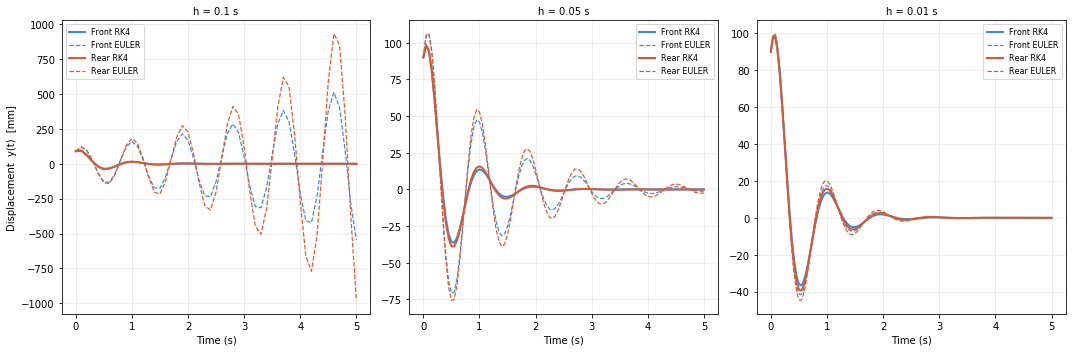

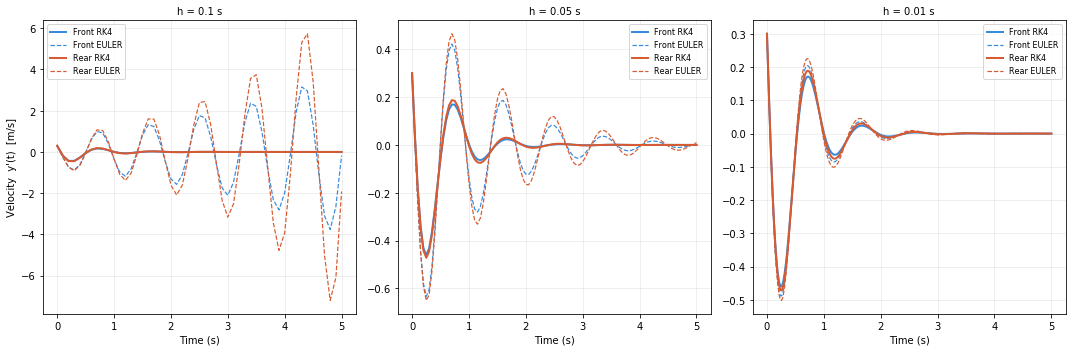

In [6]:
STEP_SIZES = [0.1, 0.05, 0.01]
 
# Solve for all combinations
res = {}
for h in STEP_SIZES:
    res[("front", "euler", h)] = euler_forward(m,  k,  c,  y0, v0, T_END, h)
    res[("front", "rk4",   h)] = rk4(          m,  k,  c,  y0, v0, T_END, h)
    res[("rear",  "euler", h)] = euler_forward(m0, k0, c0, y0, v0, T_END, h)
    res[("rear",  "rk4",   h)] = rk4(          m0, k0, c0, y0, v0, T_END, h)
#Style

AXLE_COLOR = {"front": "#378ADD", "rear": "#D85A30"}  # blue = front, orange = rear
LINE_STYLE = {"euler": "--", "rk4": "-"}              # dashed = Euler, solid = RK4
 
SUPTITLE = (
    "2014 Audi S4 — 90 mm Speed Bump\n"
    "Blue = Front,  Orange = Rear  |  Solid = RK4,  Dashed = Euler"
)
 

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))


 
for col, h in enumerate(STEP_SIZES):
    ax = axes1[col]
    for axle in ("front", "rear"):
        for method in ("rk4", "euler"):
            t, y1, _ = res[(axle, method, h)]
            ax.plot(t, y1 * 1000,
                    color=AXLE_COLOR[axle],
                    lw=2 if method == "rk4" else 1.2,
                    ls=LINE_STYLE[method],
                    label=f"{axle.capitalize()} {method.upper()}")
    
    ax.set_title(f"h = {h} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
 
axes1[0].set_ylabel("Displacement  y(t)  [mm]")
plt.tight_layout()
plt.show()
 

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5),)

 
for col, h in enumerate(STEP_SIZES):
    ax = axes2[col]
    for axle in ("front", "rear"):
        for method in ("rk4", "euler"):
            t, _, y2 = res[(axle, method, h)]
            ax.plot(t, y2,
                    color=AXLE_COLOR[axle],
                    lw=2 if method == "rk4" else 1.2,
                    ls=LINE_STYLE[method],
                    label=f"{axle.capitalize()} {method.upper()}")
    
    ax.set_title(f"h = {h} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
 
axes2[0].set_ylabel("Velocity  y'(t)  [m/s]")
plt.tight_layout()
plt.show()

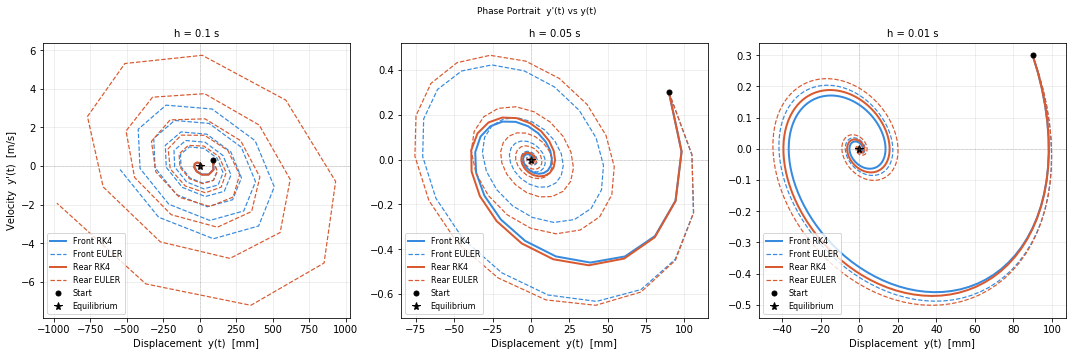

In [7]:
# ---------------------------------------------------------------------------
# Figure 3 — Phase portrait  y'(t) vs y(t)
# ---------------------------------------------------------------------------
fig3, axes3 = plt.subplots(1,3, figsize=(15, 5))
fig3.suptitle("Phase Portrait  y'(t) vs y(t)\n", fontsize=9)

for col, h in enumerate(STEP_SIZES):
    ax = axes3[col]
    for axle in ("front", "rear"):
        for method in ("rk4", "euler"):
            _, y1, y2 = res[(axle, method, h)]
            ax.plot(y1 * 1000, y2,
                    color=AXLE_COLOR[axle],
                    lw=2 if method == "rk4" else 1.2,
                    ls=LINE_STYLE[method],
                    label=f"{axle.capitalize()} {method.upper()}")

    ax.plot(y0 * 1000, v0, "ko", ms=5, label="Start")       # initial condition
    ax.plot(0, 0, "k*", ms=8,          label="Equilibrium") # target end state
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ax.axvline(0, color="gray", lw=0.5, ls=":")
    ax.set_title(f"h = {h} s", fontsize=10)
    ax.set_xlabel("Displacement  y(t)  [mm]")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

axes3[0].set_ylabel("Velocity  y'(t)  [m/s]")
plt.tight_layout()
plt.subplots_adjust(top=.88)
plt.show()


At h = 0.1 s Euler’s method demonstrates instability. Instead of finding an equilibrium, the displacement grows without bounds. RK4 is stable, producing a smooth decaying oscillation. At h = 0.05 s both methods stabilize, but Euler's still shows a slightly different curve then RK4. However by h = 0.01 s the two methods are visually the same, confirming that Euler's has converged into an appropriate solution. 

## Section 5:

Front corner natural frequency:  wn = 6.957 rad/s
Euler theoretical stability limit: h < 0.287 s
RK4   theoretical stability limit: h < 0.400 s


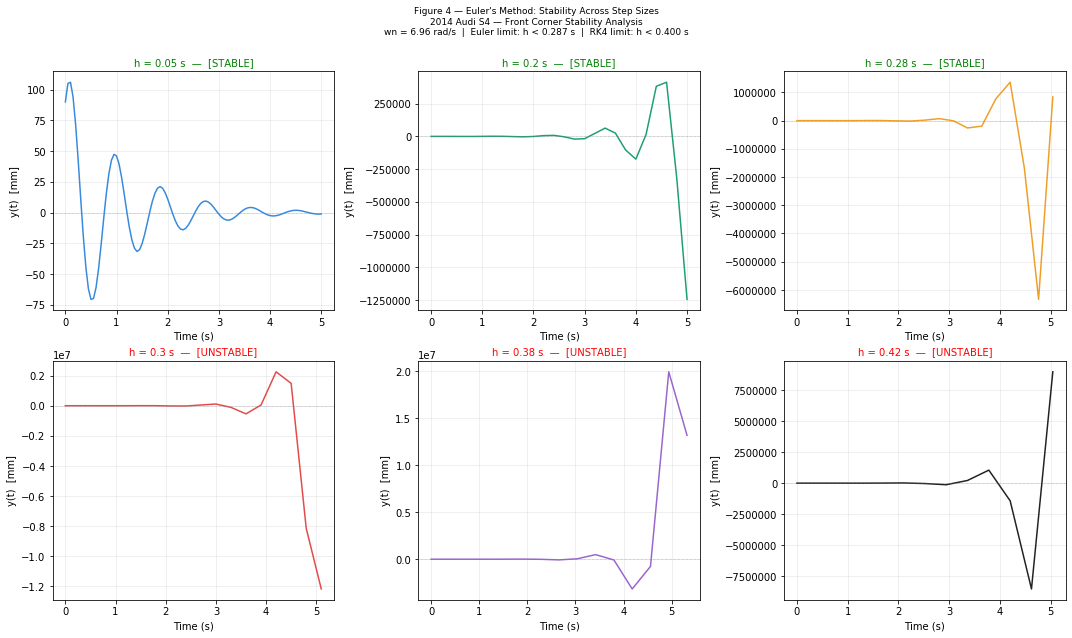

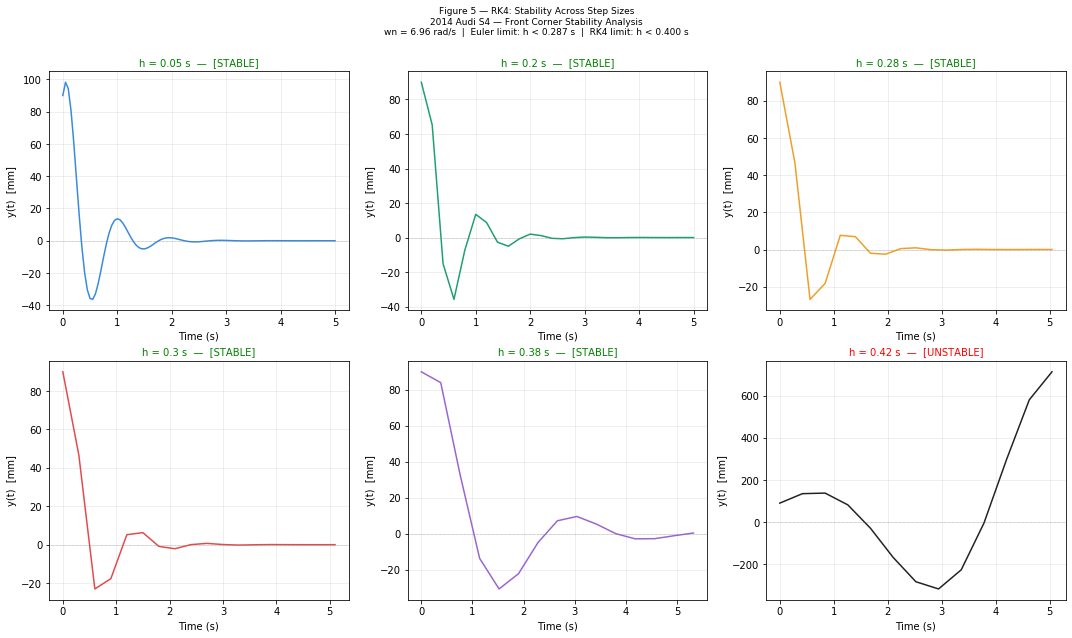

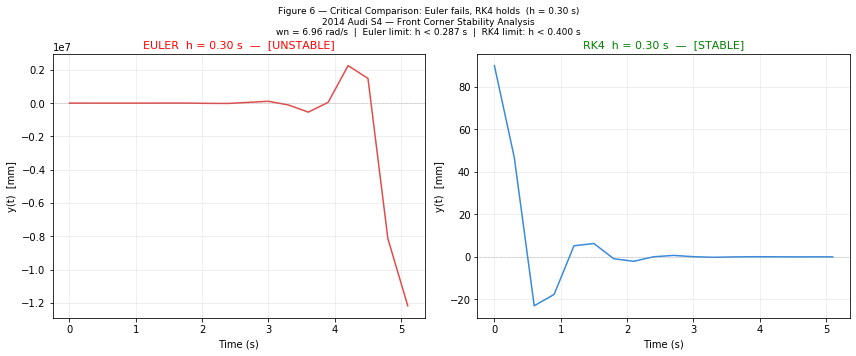


  Stability Summary — Front Corner (wn = 6.957 rad/s)
  h (s)     Euler Max |y| (mm)      RK4 Max |y| (mm)
------------------------------------------------------------
  0.05      105.98                                98.24
  0.20      1245585.12                            90.00
  0.28      6334704.02                            90.00
  0.30      12172383.92            ← UNSTABLE     90.00
  0.38      19927857.01            ← UNSTABLE     90.00
  0.42      8985298.03             ← UNSTABLE     713.37 ← UNSTABLE


In [8]:
"""
Section 5 — Demonstration of Stability Limits: Used Claude to help me with the plot routine and make sure that the Ranges
of stability made sense.
==============================================
Tests Euler and RK4 across a wide range of step sizes to identify
where each method becomes unstable for the Audi S4 suspension ODE.

For a spring-mass-damper system the theoretical stability limit
for Euler's Forward Method is:
    h < 2 / wn      where wn = sqrt(k/m)

For the front corner:  wn = sqrt(24150/499) = 6.96 rad/s
    h_critical = 2 / 6.96 = 0.287 s

RK4 has a much larger stability region:
    h < 2.785 / wn  →  h_critical = 2.785 / 6.96 = 0.400 s
"""

# ---------------------------------------------------------------------------
# Step sizes chosen to straddle both stability limits
# ---------------------------------------------------------------------------
#   Euler goes unstable around h ~ 0.29 s
#   RK4   goes unstable around h ~ 0.40 s

STEP_SIZES_STABILITY = [0.05, 0.20, 0.28, 0.30, 0.38, 0.42]

COLORS_STAB = {
    0.05: "#378ADD",   # clearly stable
    0.20: "#1D9E75",   # stable, larger step
    0.28: "#EF9F27",   # approaching Euler limit
    0.30: "#E24B4A",   # just past Euler limit
    0.38: "#9966CC",   # approaching RK4 limit
    0.42: "#222222",   # past RK4 limit
}

# Use front corner only for stability analysis 
wn_front = np.sqrt(k / m)
h_crit_euler = 2.0 / wn_front
h_crit_rk4   = 2.785 / wn_front

print(f"Front corner natural frequency:  wn = {wn_front:.3f} rad/s")
print(f"Euler theoretical stability limit: h < {h_crit_euler:.3f} s")
print(f"RK4   theoretical stability limit: h < {h_crit_rk4:.3f} s")

# ---------------------------------------------------------------------------
# Solve for all step sizes
# ---------------------------------------------------------------------------
stab_res = {}
for h in STEP_SIZES_STABILITY:
    stab_res[("euler", h)] = euler_forward(m, k, c, y0, v0, T_END, h)
    stab_res[("rk4",   h)] = rk4(m, k, c, y0, v0, T_END, h)

STAB_TITLE = (
    "2014 Audi S4 — Front Corner Stability Analysis\n"
    f"wn = {wn_front:.2f} rad/s  |  "
    f"Euler limit: h < {h_crit_euler:.3f} s  |  "
    f"RK4 limit: h < {h_crit_rk4:.3f} s"
)

# ---------------------------------------------------------------------------
# Figure 4 — Euler stability: position vs time
# ---------------------------------------------------------------------------
fig4, axes4 = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
fig4.suptitle("Figure 4 — Euler's Method: Stability Across Step Sizes\n" + STAB_TITLE, fontsize=9)

for idx, h in enumerate(STEP_SIZES_STABILITY):
    row, col = divmod(idx, 3)
    ax = axes4[row, col]
    t, y1, _ = stab_res[("euler", h)]

    ax.plot(t, y1 * 1000, color=COLORS_STAB[h], lw=1.5)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("y(t)  [mm]")

    # Label whether this step size is stable or unstable
    status = "STABLE" if h < h_crit_euler else "UNSTABLE"
    color  = "green"  if h < h_crit_euler else "red"
    ax.set_title(f"h = {h} s  —  [{status}]", fontsize=10, color=color)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# ---------------------------------------------------------------------------
# Figure 5 — RK4 stability: position vs time
# ---------------------------------------------------------------------------
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
fig5.suptitle("Figure 5 — RK4: Stability Across Step Sizes\n" + STAB_TITLE, fontsize=9)

for idx, h in enumerate(STEP_SIZES_STABILITY):
    row, col = divmod(idx, 3)
    ax = axes5[row, col]
    t, y1, _ = stab_res[("rk4", h)]

    ax.plot(t, y1 * 1000, color=COLORS_STAB[h], lw=1.5)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("y(t)  [mm]")

    status = "STABLE" if h < h_crit_rk4 else "UNSTABLE"
    color  = "green"  if h < h_crit_rk4 else "red"
    ax.set_title(f"h = {h} s  —  [{status}]", fontsize=10, color=color)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# ---------------------------------------------------------------------------
# Figure 6 — Side-by-side at the critical step sizes
#             Shows Euler failing while RK4 still holds
# ---------------------------------------------------------------------------
fig6, axes6 = plt.subplots(1, 2, figsize=(12, 5))
fig6.suptitle(
    "Figure 6 — Critical Comparison: Euler fails, RK4 holds  (h = 0.30 s)\n"
    + STAB_TITLE, fontsize=9
)

for ax, method in zip(axes6, ("euler", "rk4")):
    t, y1, _ = stab_res[(method, 0.30)]

    # Clip y-axis for readability if Euler explodes
    ax.plot(t, y1 * 1000, color="#E24B4A" if method == "euler" else "#378ADD", lw=1.5)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("y(t)  [mm]")
    ax.grid(True, alpha=0.25)

    status = "UNSTABLE" if method == "euler" else "STABLE"
    color  = "red"      if method == "euler" else "green"
    ax.set_title(f"{method.upper()}  h = 0.30 s  —  [{status}]", fontsize=11, color=color)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig("fig6_critical_comparison.png", dpi=150)
plt.show()

# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("  Stability Summary — Front Corner (wn = {:.3f} rad/s)".format(wn_front))
print("="*60)
print(f"  {'h (s)':<8}  {'Euler Max |y| (mm)':<22}  {'RK4 Max |y| (mm)'}")
print("-"*60)
for h in STEP_SIZES_STABILITY:
    _, y1_e, _ = stab_res[("euler", h)]
    _, y1_r, _ = stab_res[("rk4",   h)]
    max_e = np.max(np.abs(y1_e)) * 1000
    max_r = np.max(np.abs(y1_r)) * 1000
    flag_e = " ← UNSTABLE" if h >= h_crit_euler else ""
    flag_r = " ← UNSTABLE" if h >= h_crit_rk4   else ""
    print(f"  {h:<8.2f}  {max_e:<22.2f}{flag_e:<14}  {max_r:.2f}{flag_r}")
print("="*60)

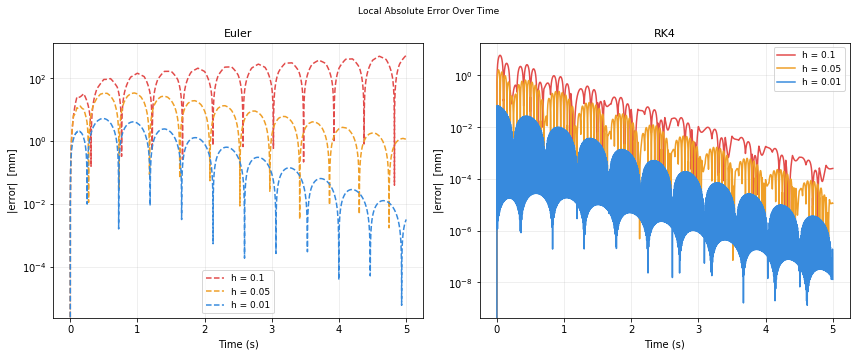

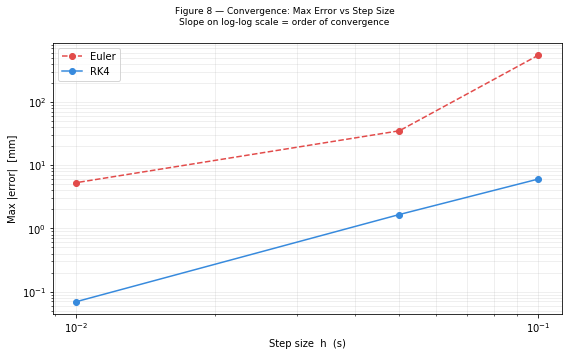

In [9]:
"""
Section 5 — Error Analysis
===========================
Fine RK4 (h = 0.001 s) is used as the reference "true" solution.
Error = | y_method(t) - y_reference(t) |
"""

import numpy as np
import matplotlib.pyplot as plt

# Reference solution
H_REF = 0.001
t_ref, y1_ref, _ = rk4(m, k, c, y0, v0, T_END, H_REF)

STEP_SIZES_ERR = [0.1, 0.05, 0.01]
COLORS = {0.1: "#E24B4A", 0.05: "#EF9F27", 0.01: "#378ADD"}

# ---------------------------------------------------------------------------
# Figure 7 — Local error over time for each step size
# ---------------------------------------------------------------------------
fig7, axes7 = plt.subplots(1, 2, figsize=(12, 5))
fig7.suptitle(
    "Local Absolute Error Over Time\n",
    fontsize=9
)

for h in STEP_SIZES_ERR:
    
    t_e, y1_e, _ = euler_forward(m, k, c, y0, v0, T_END, h)
    err_e = np.abs(np.interp(t_ref, t_e, y1_e) - y1_ref) * 1000

    
    t_r, y1_r, _ = rk4(m, k, c, y0, v0, T_END, h)
    err_r = np.abs(np.interp(t_ref, t_r, y1_r) - y1_ref) * 1000

    axes7[0].plot(t_ref, err_e, color=COLORS[h], lw=1.5, ls="--", label=f"h = {h}")
    axes7[1].plot(t_ref, err_r, color=COLORS[h], lw=1.5,           label=f"h = {h}")

for ax, title in zip(axes7, ("Euler", "RK4")):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|error|  [mm]")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# ---------------------------------------------------------------------------
# Figure 8 — Max error vs step size (convergence)
# ---------------------------------------------------------------------------
h_vals, max_e, max_r = [], [], []

for h in STEP_SIZES_ERR:
    t_e, y1_e, _ = euler_forward(m, k, c, y0, v0, T_END, h)
    t_r, y1_r, _ = rk4(          m, k, c, y0, v0, T_END, h)
    max_e.append(np.max(np.abs(np.interp(t_ref, t_e, y1_e) - y1_ref)) * 1000)
    max_r.append(np.max(np.abs(np.interp(t_ref, t_r, y1_r) - y1_ref)) * 1000)
    h_vals.append(h)

h_vals = np.array(h_vals)
max_e  = np.array(max_e)
max_r  = np.array(max_r)

fig8, ax8 = plt.subplots(figsize=(8, 5))
fig8.suptitle(
    "Figure 8 — Convergence: Max Error vs Step Size\n"
    "Slope on log-log scale = order of convergence",
    fontsize=9
)

ax8.loglog(h_vals, max_e, "o--", color="#E24B4A", lw=1.5, label="Euler")
ax8.loglog(h_vals, max_r, "o-",  color="#378ADD", lw=1.5, label="RK4")

ax8.set_xlabel("Step size  h  (s)")
ax8.set_ylabel("Max |error|  [mm]")
ax8.grid(True, alpha=0.25, which="both")
ax8.legend(fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.show()

A Numerical method is stable when small errors that occur at each step remain bounded and do not grow exponentially. An unstable approach happens when the inverse occurs, leading to large oscillations that are not representative of the system at hand. 

Each simulation models a single corner of the 2014 Audi S4 as it strikes a 90 mm speed bump which is the height of a standard residential speed bump. The displacement y(t) represents how far that corner moves vertically from its unstretched position, and y'(t) represents how fast it is moving at an instant that follows. The goal of the suspension is to absorb the initial impact energy and return the wheel and chassis to equilibrium as smoothly and quickly as possible.

The S4 suspension behaves as a well-tuned underdamped system. It absorbs the 90 mm impact without bottoming out, oscillates briefly, and returns to equilibrium within 3–4 seconds. The matched front and rear natural frequencies prevent pitch motion, while the slightly higher front damping ratio ensures the front corner leads the rear in settling. 

## Section 6:


RK4 outperformed Euler’s method in every category for this problem. RK4 remained more accurate at larger step sizes, and was able to produce significantly less error. That being said, RK4 requires 4 evaluations of the ODE per time step, compared to Euler’s 1.This means that RK4 uses 4x the computation power. However because RK4 converges so much faster it reaches a given accuracy level at a much larger step size. Lending RK4 to be cheaper and more accurate for this exact problem.


Lessons Learned:

Step size is not just an accuracy parameter it's a stability parameter. The most important insight from this project is that choosing too large a step size does not produce a slightly wrong answer; it produces a completely meaningless one. The Euler instability at h = 0.1 s generated displacements of thousands of millimetres, which no physical sanity check would ever accept as a suspension response. This means numerical results should always be validated by running at multiple step sizes and confirming convergence before drawing any engineering conclusions.